# RGB display transformations

Prepared for Shivam Singh · MathTech

## Theory
Night and thermal-style views are visual simulations. Standard RGB cameras do not measure temperature or gain infrared sensitivity from a colormap.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.visualization.filters import transform
frame = demo_frame(40)
modes = ["RGB", "Grayscale", "Canny", "High Contrast", "Night Vision", "Thermal Style"]
outputs = [transform(frame, replace(settings, view_mode=mode)) for mode in modes]


## Visualization

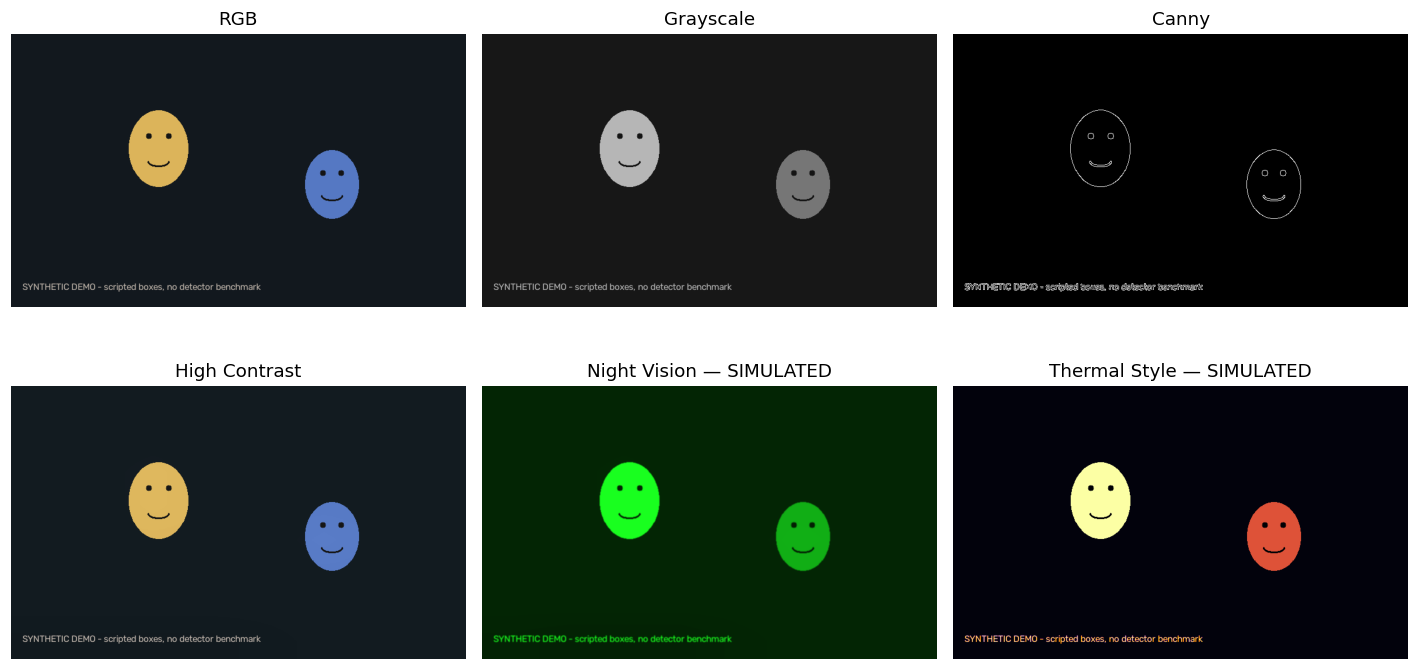

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, output, mode in zip(axes.flat, outputs, modes):
    ax.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    ax.set_title(mode + (" — SIMULATED" if mode in ["Night Vision", "Thermal Style"] else "")); ax.axis("off")
plt.tight_layout(); plt.show()


## Experiment

In [4]:
original = frame.copy()
for mode in modes: transform(frame, replace(settings, view_mode=mode))
assert np.array_equal(original, frame)
print("Source frame is unchanged by every display transformation")


Source frame is unchanged by every display transformation


## Observations
Experiment with gain, brightness and noise for Night Vision. Increasing gain can amplify visible noise; it cannot recover information the sensor never captured.

## Conclusion
Treat these as contrast and color transformations, never physical thermal measurements.